# Visualize Converted SFT Parquet

Inspect rows produced by `convert_exported_convos_to_qwen3_vl_zoom_in_sft.py`.
The notebook renders the `MultiTurnSFTDataset` schema directly from parquet.


In [17]:
from pathlib import Path
import io
import json

import pandas as pd
from PIL import Image
from IPython.display import display, Markdown


In [18]:
# PARQUET_PATH = Path('/home/ywxzml3j/ywxzml3juser40/insight_doc/outputs/iq_base_eval_refactor_smoke_r1/converted_sft/train.parquet')
# PARQUET_PATH = Path('/home/ywxzml3j/ywxzml3juser40/insight_doc/outputs/insight_qwen_agent_initial_0_5_default_sys/qwen3-vl-32b-instruct/veqa_batch_0350_r2_mveqa_batch_0352_r2-dpi200_aug_noaug_maxp40/converted_sft/sft_data.parquet')
# PARQUET_PATH = Path('/scratch/ywxzml3j/likaican/mms1_rl/converted_sft/multi_agent_vsearch/arxiv_0307_sample_qwen3_region_loc_bbox_issue_fixed/O3_data_0424-dpi200_aug_noaug_maxp40-0426_resumable/sft_data.parquet')
# PARQUET_PATH = Path('/home/ywxzml3j/ywxzml3juser40/insight_doc/outputs/insight_qwen_agent_zoom_factor2_default_sys_0426_resumable/qwen3-vl-32b-instruct/O3_data_0424-dpi200_aug_noaug_maxp40/converted_sft/sft_data.parquet')
# PARQUET_PATH = Path('/scratch/ywxzml3j/likaican/mms1_rl/converted_sft/multi_agent_vsearch/arxiv_0307_sample_qwen3_region_loc_bbox_issue_fixed/O3_data_0424-dpi200_aug_noaug_maxp40-0426_train_part1_resumable/sft_data.parquet')
PARQUET_PATH = Path('/home/ywxzml3j/ywxzml3juser40/data/insight_doc/generated/O3_data_0424/train_part2c/medium/processed_gpt5_nano_rewrite/sft_data.parquet')
assert PARQUET_PATH.exists(), PARQUET_PATH
df = pd.read_parquet(PARQUET_PATH)
print('rows:', len(df))
df.head()


rows: 857


,messages,message_loss_mask,images,tools
0,[{'content': 'Your role is that of a research ...,"[False, False, True, False, True]",[{'image': 'file:///home/ywxzml3j/ywxzml3juser...,[{'function': {'description': 'Zoom in on a sp...
1,[{'content': 'Your role is that of a research ...,"[False, False, True, False, True]",[{'image': 'file:///home/ywxzml3j/ywxzml3juser...,[{'function': {'description': 'Zoom in on a sp...
2,[{'content': 'Your role is that of a research ...,"[False, False, True, False, True]",[{'image': 'file:///home/ywxzml3j/ywxzml3juser...,[{'function': {'description': 'Zoom in on a sp...
3,[{'content': 'Your role is that of a research ...,"[False, False, True, False, True, False, True,...",[{'image': 'file:///home/ywxzml3j/ywxzml3juser...,[{'function': {'description': 'Zoom in on a sp...
4,[{'content': 'Your role is that of a research ...,"[False, False, True, False, True]",[{'image': 'file:///home/ywxzml3j/ywxzml3juser...,[{'function': {'description': 'Zoom in on a sp...


In [19]:
def to_jsonable(obj):
    if hasattr(obj, 'tolist'):
        return to_jsonable(obj.tolist())
    if hasattr(obj, 'item') and not isinstance(obj, (str, bytes, bytearray)):
        try:
            return to_jsonable(obj.item())
        except Exception:
            pass
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(v) for v in obj]
    return obj

def json_default(obj):
    if hasattr(obj, 'tolist'):
        return obj.tolist()
    if hasattr(obj, 'item') and not isinstance(obj, (str, bytes, bytearray)):
        try:
            return obj.item()
        except Exception:
            pass
    return repr(obj)

def dump_json(obj):
    return json.dumps(to_jsonable(obj), ensure_ascii=False, indent=2, default=json_default)

def load_image_payload(item):
    if 'bytes' in item:
        return Image.open(io.BytesIO(item['bytes'])).convert('RGB')
    if 'image' in item:
        path = item['image']
        if path.startswith('file://'):
            path = path[7:]
        return Image.open(path).convert('RGB')
    raise ValueError(f'Unknown image payload: {item}')

def render_text_with_images(text, images, image_ptr):
    chunks = text.split('<image>')
    for j, chunk in enumerate(chunks):
        if chunk:
            display(Markdown(f'```text\n{chunk}\n```'))
        if j < len(chunks) - 1:
            if image_ptr < len(images):
                display(images[image_ptr])
                image_ptr += 1
            else:
                display(Markdown('`[missing image]`'))
    return image_ptr

def display_converted_row(idx: int):
    row = df.iloc[idx]
    images = [load_image_payload(x) for x in row['images']]
    image_ptr = 0

    display(Markdown(f'## Row {idx}'))
    display(Markdown(f'`message_loss_mask`: {to_jsonable(row["message_loss_mask"])}'))

    for i, msg in enumerate(row['messages']):
        role = msg.get('role')
        content = msg.get('content')
        display(Markdown(f'### {i}. {role}'))

        tool_calls = msg.get('tool_calls')
        if tool_calls:
            display(Markdown('**tool_calls**'))
            display(Markdown(f'```json\n{dump_json(tool_calls)}\n```'))

        if isinstance(content, list):
            for part in content:
                part_type = part.get('type')
                if part_type == 'text':
                    text = part.get('text', '')
                    if text:
                        display(Markdown(f'```text\n{text}\n```'))
                elif part_type == 'image':
                    if image_ptr < len(images):
                        display(images[image_ptr])
                        image_ptr += 1
                    else:
                        display(Markdown('`[missing image]`'))
                else:
                    display(Markdown(f'```json\n{dump_json(part)}\n```'))
            continue

        if isinstance(content, str):
            image_ptr = render_text_with_images(content, images, image_ptr)
            if i == 0 and role == 'system':
                display(Markdown('**tools schema**'))
                display(Markdown(f'```json\n{dump_json(row["tools"])}\n```'))
            continue

        display(Markdown(f'```json\n{dump_json(content)}\n```'))
        if i == 0 and role == 'system':
            display(Markdown('**tools schema**'))
            display(Markdown(f'```json\n{dump_json(row["tools"])}\n```'))


## Row 200

`message_loss_mask`: [False, False, True, False, True, False, True]

### 0. system

```text
Your role is that of a research assistant specializing in visual information. Answer questions about images by looking at them closely and then using research tools. Please follow this structured thinking process and show your work.

Start an iterative loop for each question:

- **First, look closely:** Begin with a detailed description of the image, paying attention to the user's question. List what you can tell just by looking, and what you'll need to look up.
- **Next, find information:** Use a tool to research the things you need to find out.
- **Then, review the findings:** Carefully analyze what the tool tells you and decide on your next action.

Continue this loop until your research is complete.

To finish, bring everything together in a clear, synthesized answer that fully responds to the user's question.
```

**tools schema**

```json
[
  {
    "function": {
      "description": "Zoom in on a specific region of an image by cropping it based on a bounding box (bbox) and an object label.",
      "name": "image_zoom_in_tool",
      "parameters": {
        "properties": {
          "bbox_2d": {
            "description": "The bounding box of the region to zoom in, as [x1, y1, x2, y2], where (x1, y1) is the top-left corner and (x2, y2) is the bottom-right corner.",
            "items": {
              "type": "number"
            },
            "maxItems": 4,
            "minItems": 4,
            "type": "array"
          },
          "img_idx": {
            "description": "The index of the zoomed-in image (starting from 0).",
            "type": "number"
          },
          "label": {
            "description": "The name or label of the object in the specified bounding box.",
            "type": "string"
          }
        },
        "required": [
          "bbox_2d",
          "label",
          "img_idx"
        ],
        "type": "object"
      }
    },
    "type": "function"
  }
]
```

### 1. user

```text
Image 0:
```

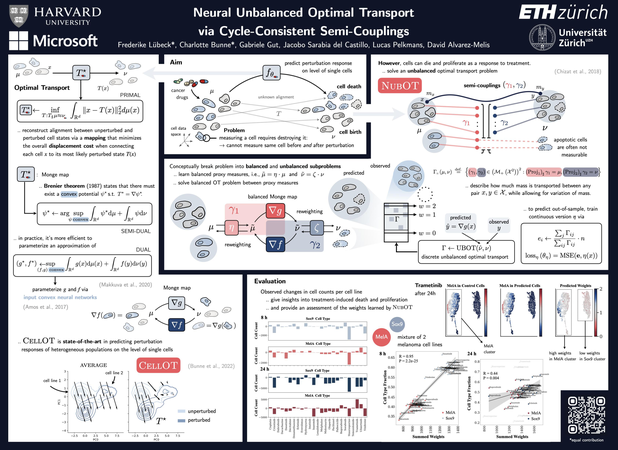

```text


What is a principal finding of the NUBOT study?
```

### 2. assistant

**tool_calls**

```json
[
  {
    "function": {
      "arguments": "{\"img_idx\": 0, \"label\": \"middle-right panel showing NUBOT diagram, observed vs predicted plots and text\", \"bbox_2d\": [594, 349, 984, 600]}",
      "name": "image_zoom_in_tool"
    },
    "type": "function"
  }
]
```

```text
I should zoom into the middle-right area where the NUBOT illustration and findings are likely located (center-right of the poster). This will show captions or a highlighted "observed" or "predicted" results that state principal findings.
```

### 3. tool

```text
Image 1:
```

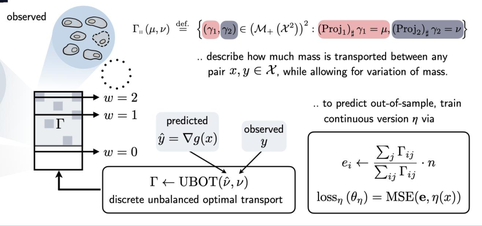

### 4. assistant

**tool_calls**

```json
[
  {
    "function": {
      "arguments": "{\"img_idx\": 0, \"label\": \"right-side evaluation panel with plots and summary text about observed vs predicted changes in cell counts and model performance\", \"bbox_2d\": [398, 613, 987, 984]}",
      "name": "image_zoom_in_tool"
    },
    "type": "function"
  }
]
```

```text
The principal finding is likely summarized in the evaluation/results panel on the right showing that NUBOT predicts observed changes in cell counts and outperforms baselines. I'll zoom into the right-side evaluation plots and accompanying text to read the key conclusion.
```

### 5. tool

```text
Image 2:
```

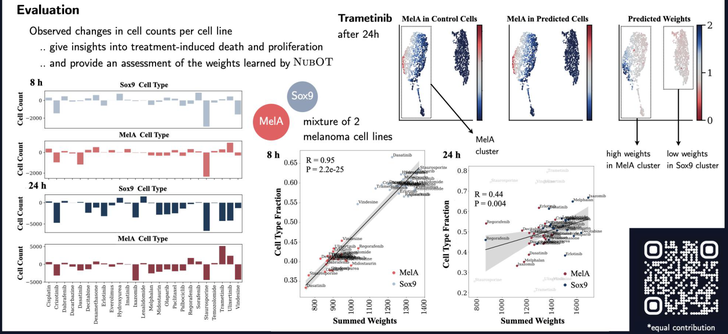

### 6. assistant

```text
NUBOT's principal finding is that it can accurately predict treatment-induced changes in cell composition and cell counts; its learned weights correlate strongly with observed shifts, with a reported R=0.95 at 8 h between summed predicted weights and measured MelA/Sox9 fractions, indicating which cell types proliferate or die under treatment.
```

In [20]:
idx = 200
display_converted_row(idx)
